Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8828 - loss: 0.8510 - val_accuracy: 0.9707 - val_loss: 0.6033
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9736 - loss: 0.5919 - val_accuracy: 0.9750 - val_loss: 0.5825
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.5605 - val_accuracy: 0.9767 - val_loss: 0.5719
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9884 - loss: 0.5445 - val_accuracy: 0.9775 - val_loss: 0.5646
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9913 - loss: 0.5332 - val_accuracy: 0.9786 - val_loss: 0.5591
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9925 - loss: 0.5267 - val_accuracy: 0.9770 - val_loss: 0.5601
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9943 - loss: 0.5222 - val_accuracy: 0.9796 - val_loss: 0.5570
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9949 - loss: 0.5188 -

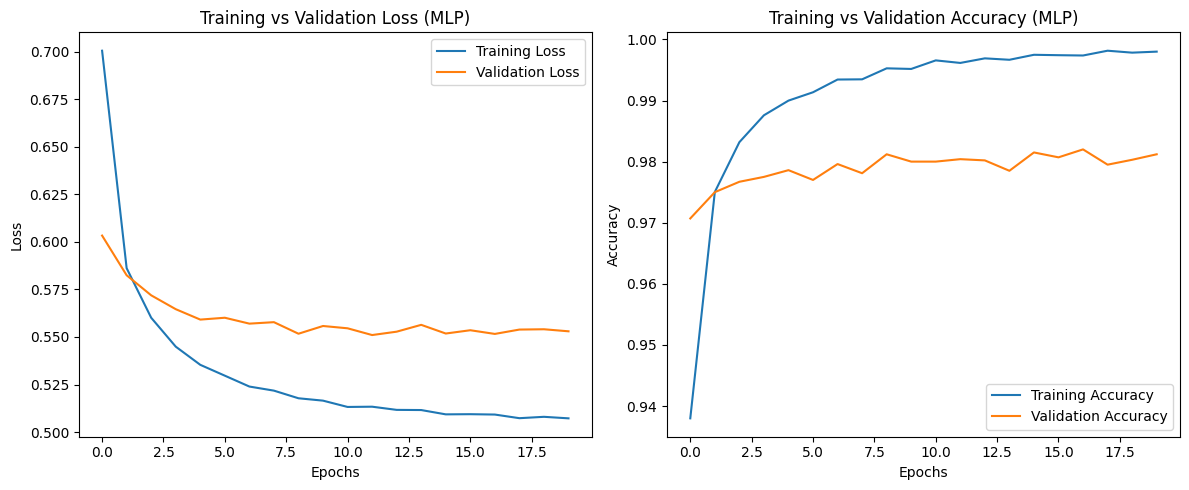

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

model = Sequential([
    Dense(160, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(48, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

learn_history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(learn_history.history["loss"], label="Training Loss")
plt.plot(learn_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(learn_history.history["accuracy"], label="Training Accuracy")
plt.plot(learn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8842 - loss: 0.4125 - val_accuracy: 0.9678 - val_loss: 0.1080
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9655 - loss: 0.1136 - val_accuracy: 0.9729 - val_loss: 0.0855
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9719 - loss: 0.0887 - val_accuracy: 0.9710 - val_loss: 0.0899
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9793 - loss: 0.0673 - val_accuracy: 0.9784 - val_loss: 0.0700
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9810 - loss: 0.0570 - val_accuracy: 0.9758 - val_loss: 0.0789
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9847 - loss: 0.0487 - val_accuracy: 0.9797 - val_loss: 0.0681
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9862 - loss: 0.0415 - val_accuracy: 0.9788 - val_loss: 0.0678
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9867 - loss: 0.0395 -

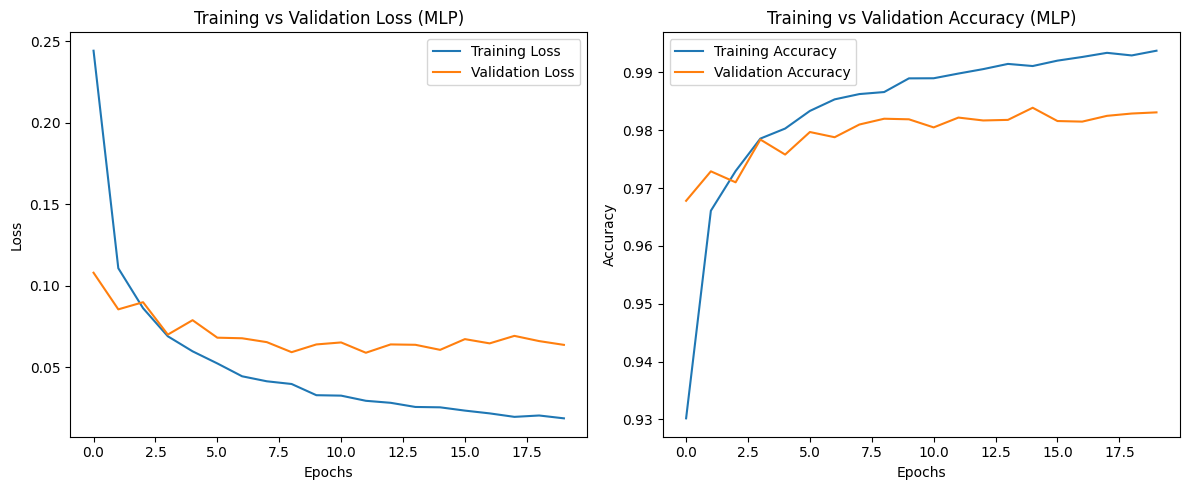

In [ ]:
#batch
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

model = Sequential([
    Dense(128, input_shape=(784,)),
    BatchNormalization(),
    Activation("relu"),

    Dense(64),
    BatchNormalization(),
    Activation("relu"),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

learn_history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(learn_history.history["loss"], label="Training Loss")
plt.plot(learn_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(learn_history.history["accuracy"], label="Training Accuracy")
plt.plot(learn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8305 - loss: 1.8246 - val_accuracy: 0.9244 - val_loss: 1.0169
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9190 - loss: 1.0126 - val_accuracy: 0.9317 - val_loss: 0.9521
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9312 - loss: 0.9401 - val_accuracy: 0.9381 - val_loss: 0.8902
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9355 - loss: 0.8983 - val_accuracy: 0.9461 - val_loss: 0.8565
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9380 - loss: 0.8733 - val_accuracy: 0.9271 - val_loss: 0.8779
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9409 - loss: 0.8583 - val_accuracy: 0.9466 - val_loss: 0.8269
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9407 - loss: 0.8411 - val_accuracy: 0.9445 - val_loss: 0.8230
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9449 - loss: 0.8303 - 

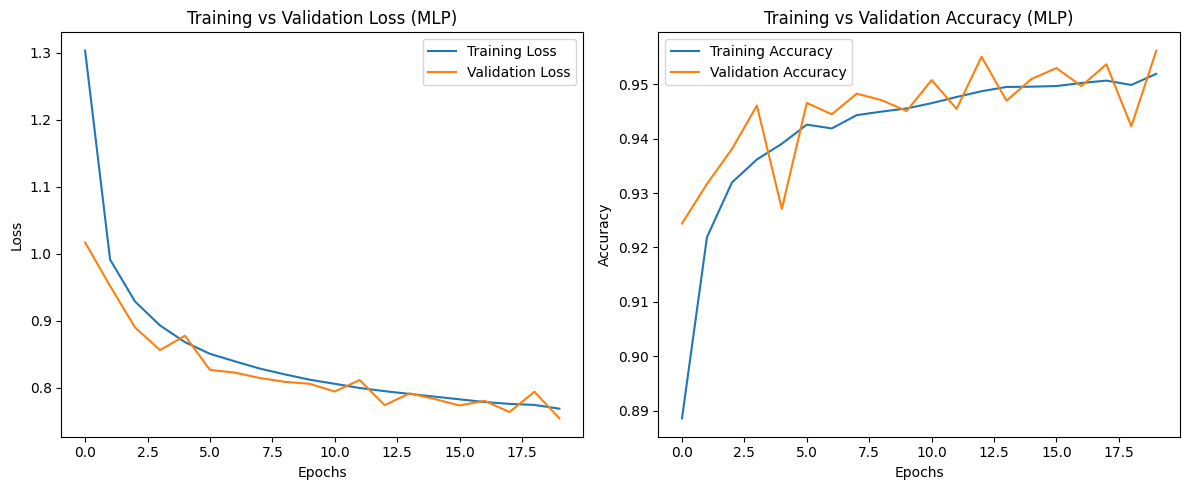

In [ ]:
# L2 regulrization
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

model = Sequential([
    Dense(160,
          activation="relu",
          kernel_regularizer=L2(0.01),
          input_shape=(784,)),

    Dense(64,
          activation="relu",
          kernel_regularizer=L2(0.01)),

    Dense(48,
          activation="relu",
          kernel_regularizer=L2(0.01)),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

learn_history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(learn_history.history["loss"], label="Training Loss")
plt.plot(learn_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(learn_history.history["accuracy"], label="Training Accuracy")
plt.plot(learn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7748 - loss: 1.1141 - val_accuracy: 0.9593 - val_loss: 0.6310
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9489 - loss: 0.7221 - val_accuracy: 0.9700 - val_loss: 0.5887
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9619 - loss: 0.6634 - val_accuracy: 0.9659 - val_loss: 0.5900
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9682 - loss: 0.6355 - val_accuracy: 0.9723 - val_loss: 0.5720
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9688 - loss: 0.6235 - val_accuracy: 0.9731 - val_loss: 0.5744
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9716 - loss: 0.6139 - val_accuracy: 0.9741 - val_loss: 0.5713
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9731 - loss: 0.6069 - val_accuracy: 0.9764 - val_loss: 0.5667
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.6016 - 

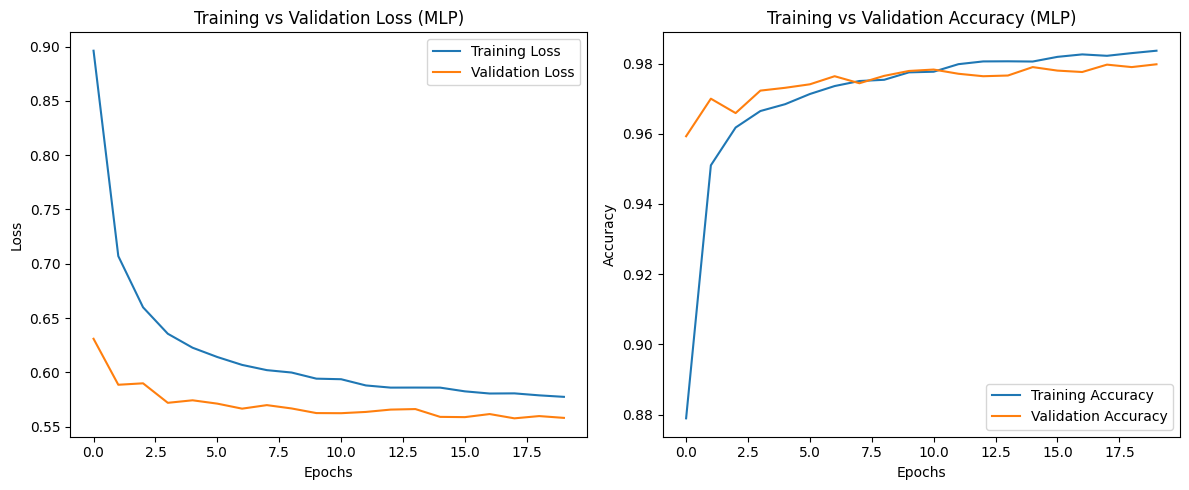

In [ ]:
#dropout
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

model = Sequential([
    Dense(160, activation="relu", input_shape=(784,)),
    Dropout(0.25),

    Dense(64, activation="relu"),
    Dropout(0.25),

    Dense(48, activation="relu"),
    Dropout(0.25),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

learn_history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(learn_history.history["loss"], label="Training Loss")
plt.plot(learn_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(learn_history.history["accuracy"], label="Training Accuracy")
plt.plot(learn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (MLP)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
